# K-Nearest Neighbor (KNN) Classification using Iris Dataset

**Dataset:** Iris Dataset  
**Features:** Sepal Length, Sepal Width, Petal Length, Petal Width  
**Classes:** Setosa, Versicolor, Virginica


## Objective
To implement the **K-Nearest Neighbor (KNN)** algorithm to classify Iris flowers into Setosa, Versicolor, and Virginica classes.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

## 1. Load the Dataset

Keep `Iris.csv` in the same folder as this notebook.

In [30]:
df = pd.read_csv('Iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [31]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum())

print('\nClass distribution:')
print(df.iloc[:, -1].value_counts())

Shape: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 2. Select Features and Target

In [32]:
df.columns = df.columns.str.strip()

# Rename columns to standard names
df = df.rename(columns={
    'SepalLengthCm': 'sepal_length',
    'SepalWidthCm': 'sepal_width',
    'PetalLengthCm': 'petal_length',
    'PetalWidthCm': 'petal_width',
    'Species': 'species'
})

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

print("Features:", X.columns.tolist())
print("Classes:", y.unique())

Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Classes: <ArrowStringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


## 3. Split the Dataset

80% data is used for training and 20% for testing.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 120
Testing samples: 30


## 4. Standardize the Features

KNN uses distance between data points, so feature scaling is important.

In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Train the KNN Model

Here, `K = 5`, meaning the 5 nearest training points are considered for classification.

In [35]:
k = 5

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print('KNN model trained successfully with K =', k)

KNN model trained successfully with K = 5


## 6. Evaluate the Model

In [36]:
accuracy = accuracy_score(y_test, y_pred)

print('Accuracy:', round(accuracy * 100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 93.33 %

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



## 7. Confusion Matrix

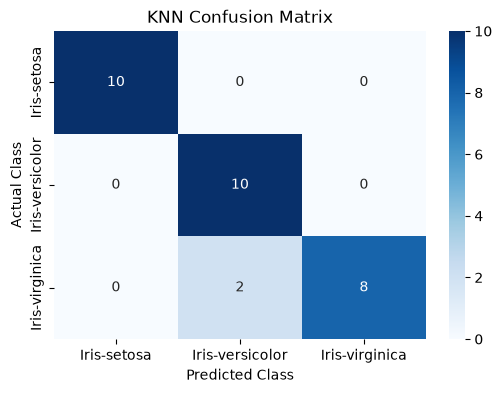

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('KNN Confusion Matrix')
plt.show()

## 8. Find the Best Value of K

We test different K values and compare their accuracy.

In [38]:
k_values = range(1, 16)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, pred))

best_k = list(k_values)[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print('Best K:', best_k)
print('Best Accuracy:', round(best_accuracy * 100, 2), '%')

Best K: 1
Best Accuracy: 96.67 %


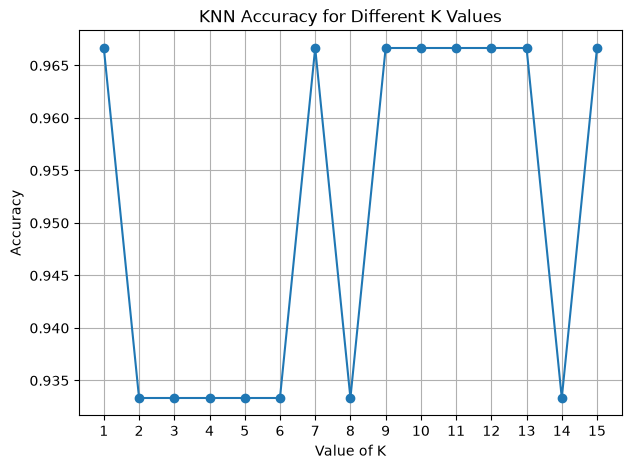

In [39]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Value of K')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different K Values')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

## 9. Test a Sample Flower

Enter measurements for a new flower and let KNN predict its class.

In [40]:
sample = [[5.1, 3.5, 1.4, 0.2]]
sample_scaled = scaler.transform(sample)

prediction = knn.predict(sample_scaled)
print('Predicted flower:', prediction[0])

Predicted flower: Iris-setosa


c:\Users\SHARAYU SHELKE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Conclusion

- KNN classifies flowers based on the classes of their nearest data points.
- Feature scaling is used because KNN is distance-based.
- The model is evaluated using accuracy, classification report, and confusion matrix.
- Different values of K are tested to observe their effect on accuracy.
- The Iris flowers are classified into **Setosa, Versicolor, and Virginica**.

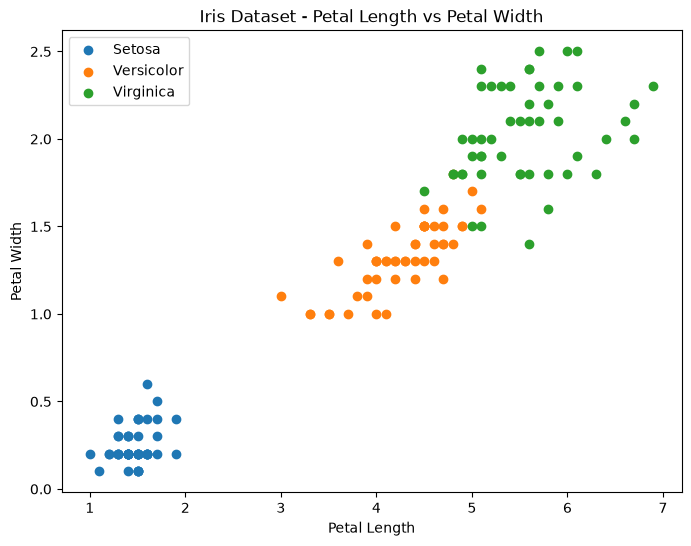

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(X.loc[y == 'Iris-setosa', 'petal_length'],
            X.loc[y == 'Iris-setosa', 'petal_width'],
            label='Setosa')

plt.scatter(X.loc[y == 'Iris-versicolor', 'petal_length'],
            X.loc[y == 'Iris-versicolor', 'petal_width'],
            label='Versicolor')

plt.scatter(X.loc[y == 'Iris-virginica', 'petal_length'],
            X.loc[y == 'Iris-virginica', 'petal_width'],
            label='Virginica')

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Iris Dataset - Petal Length vs Petal Width')
plt.legend()
plt.show()